##Counterfactual Clinical Decision Support using Temporal Transformers on EHR Data

##Imports

In [1]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


##Set random seed

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

##Create synthetic demo dataset

In [3]:
num_patients = 2000
seq_len = 12
num_features = 8
num_treatments = 3  # 0: no treatment, 1: drug A, 2: drug B

rows = []

for pid in range(num_patients):
    baseline = np.random.normal(0, 1, num_features)
    severity = np.random.uniform(0, 1)

    treatment = np.random.choice([0, 1, 2], p=[0.2, 0.4, 0.4])

    patient_seq = []
    for t in range(seq_len):
        noise = np.random.normal(0, 0.3, num_features)
        trend = (t / seq_len) * severity

        if treatment == 1:   # drug A
            treatment_effect = -0.3
        elif treatment == 2: # drug B
            treatment_effect = 0.2
        else:
            treatment_effect = 0.4

        features = baseline + trend + treatment_effect + noise
        patient_seq.append(features)

    patient_seq = np.array(patient_seq)

    # Future risk / outcome label
    final_score = patient_seq[-1].mean()
    outcome = 1 if final_score > 0.5 else 0   # 1 = risky, 0 = stable

    for t in range(seq_len):
        row = {
            "patient_id": pid,
            "time_idx": t,
            "treatment": treatment,
            "outcome": outcome
        }
        for f in range(num_features):
            row[f"feature_{f}"] = patient_seq[t, f]
        rows.append(row)

df = pd.DataFrame(rows)
df.head()

,patient_id,time_idx,treatment,outcome,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7
0,0,0,2,1,0.555872,0.224504,0.708663,1.583311,0.038435,-0.608121,1.261737,0.798748
1,0,1,2,1,0.394580,0.157725,0.576997,1.301054,0.407257,-0.100154,1.801187,0.541726
2,0,2,2,1,0.536830,0.098443,0.505821,1.839170,-0.210914,-0.118214,1.602132,1.526549
3,0,3,2,1,0.697811,-0.250431,1.099598,1.361923,0.033652,-0.616892,1.385903,1.031639
4,0,4,2,1,0.925116,0.120008,0.819856,1.639560,-0.470848,-0.243229,1.647883,1.291433


##View sample data

In [4]:
print(df.shape)
print(df.head())

print("\nUnique patients:", df["patient_id"].nunique())
print("Unique treatments:", df["treatment"].unique())
print("Outcome distribution:\n", df.groupby("patient_id")["outcome"].first().value_counts())

(24000, 12)
   patient_id  time_idx  treatment  outcome  feature_0  feature_1  feature_2  \
0           0         0          2        1   0.555872   0.224504   0.708663   
1           0         1          2        1   0.394580   0.157725   0.576997   
2           0         2          2        1   0.536830   0.098443   0.505821   
3           0         3          2        1   0.697811  -0.250431   1.099598   
4           0         4          2        1   0.925116   0.120008   0.819856   

   feature_3  feature_4  feature_5  feature_6  feature_7  
0   1.583311   0.038435  -0.608121   1.261737   0.798748  
1   1.301054   0.407257  -0.100154   1.801187   0.541726  
2   1.839170  -0.210914  -0.118214   1.602132   1.526549  
3   1.361923   0.033652  -0.616892   1.385903   1.031639  
4   1.639560  -0.470848  -0.243229   1.647883   1.291433  

Unique patients: 2000
Unique treatments: [2 0 1]
Outcome distribution:
 outcome
1    1036
0     964
Name: count, dtype: int64


##Preprocess into sequences

In [5]:
feature_cols = [c for c in df.columns if c.startswith("feature_")]

patient_groups = df.groupby("patient_id")

X_list = []
T_list = []
y_list = []

for pid, group in patient_groups:
    group = group.sort_values("time_idx")

    x_seq = group[feature_cols].values              # [seq_len, num_features]
    treatment_seq = group["treatment"].values       # [seq_len]
    label = group["outcome"].iloc[0]                # single label per patient

    X_list.append(x_seq)
    T_list.append(treatment_seq)
    y_list.append(label)

X = np.array(X_list, dtype=np.float32)   # [N, seq_len, num_features]
T = np.array(T_list, dtype=np.int64)     # [N, seq_len]
y = np.array(y_list, dtype=np.int64)     # [N]

print("X shape:", X.shape)
print("T shape:", T.shape)
print("y shape:", y.shape)

X shape: (2000, 12, 8)
T shape: (2000, 12)
y shape: (2000,)


##Normalize features

##Normalize features

In [6]:
N, S, F = X.shape

scaler = StandardScaler()
X_2d = X.reshape(-1, F)
X_2d = scaler.fit_transform(X_2d)
X = X_2d.reshape(N, S, F)

print("Normalized X shape:", X.shape)

Normalized X shape: (2000, 12, 8)


##Train/test split

In [7]:
X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(
    X, T, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (1600, 12, 8) (1600,)
Test : (400, 12, 8) (400,)


##Dataset and DataLoader

In [8]:
class EHRDataset(Dataset):
    def __init__(self, X, T, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.T = torch.tensor(T, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.T[idx], self.y[idx]

train_dataset = EHRDataset(X_train, T_train, y_train)
test_dataset = EHRDataset(X_test, T_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

##Positional encoding

In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len]

##Temporal Transformer with treatment embedding

In [10]:
class CounterfactualTemporalTransformer(nn.Module):
    def __init__(self, num_features, num_treatments, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()

        self.feature_proj = nn.Linear(num_features, d_model)
        self.treatment_embed = nn.Embedding(num_treatments, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x, treatment_seq):
        x_embed = self.feature_proj(x)                       # [B, S, d_model]
        t_embed = self.treatment_embed(treatment_seq)       # [B, S, d_model]

        h = x_embed + t_embed
        h = self.pos_encoder(h)
        h = self.transformer(h)                             # [B, S, d_model]

        pooled = h[:, -1, :]                                # last time step
        logits = self.classifier(pooled).squeeze(-1)        # [B]
        return logits

##Initialize model

In [11]:
model = CounterfactualTemporalTransformer(
    num_features=num_features,
    num_treatments=num_treatments,
    d_model=64,
    nhead=4,
    num_layers=2,
    dropout=0.1
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

CounterfactualTemporalTransformer(
  (feature_proj): Linear(in_features=8, out_features=64, bias=True)
  (treatment_embed): Embedding(3, 64)
  (pos_encoder): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dro

##Training loop

In [12]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for x_batch, t_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        t_batch = t_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(x_batch, t_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_batch, t_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            t_batch = t_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch, t_batch)
            loss = criterion(logits, y_batch)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            total_loss += loss.item()
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), acc

##Run training

In [13]:
num_epochs = 15

train_losses = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

Epoch 1/15 | Train Loss: 0.3699 | Test Loss: 0.1644 | Test Acc: 0.9350
Epoch 2/15 | Train Loss: 0.1406 | Test Loss: 0.1933 | Test Acc: 0.9225
Epoch 3/15 | Train Loss: 0.0964 | Test Loss: 0.1053 | Test Acc: 0.9525
Epoch 4/15 | Train Loss: 0.0769 | Test Loss: 0.0624 | Test Acc: 0.9675
Epoch 5/15 | Train Loss: 0.0660 | Test Loss: 0.0795 | Test Acc: 0.9600
Epoch 6/15 | Train Loss: 0.0556 | Test Loss: 0.1263 | Test Acc: 0.9550
Epoch 7/15 | Train Loss: 0.0640 | Test Loss: 0.0960 | Test Acc: 0.9500
Epoch 8/15 | Train Loss: 0.0704 | Test Loss: 0.0832 | Test Acc: 0.9600
Epoch 9/15 | Train Loss: 0.0445 | Test Loss: 0.0753 | Test Acc: 0.9625
Epoch 10/15 | Train Loss: 0.0748 | Test Loss: 0.0643 | Test Acc: 0.9675
Epoch 11/15 | Train Loss: 0.0655 | Test Loss: 0.1271 | Test Acc: 0.9600
Epoch 12/15 | Train Loss: 0.0313 | Test Loss: 0.1631 | Test Acc: 0.9625
Epoch 13/15 | Train Loss: 0.0445 | Test Loss: 0.0727 | Test Acc: 0.9700
Epoch 14/15 | Train Loss: 0.0245 | Test Loss: 0.1399 | Test Acc: 0.9500
E

##Plot training history

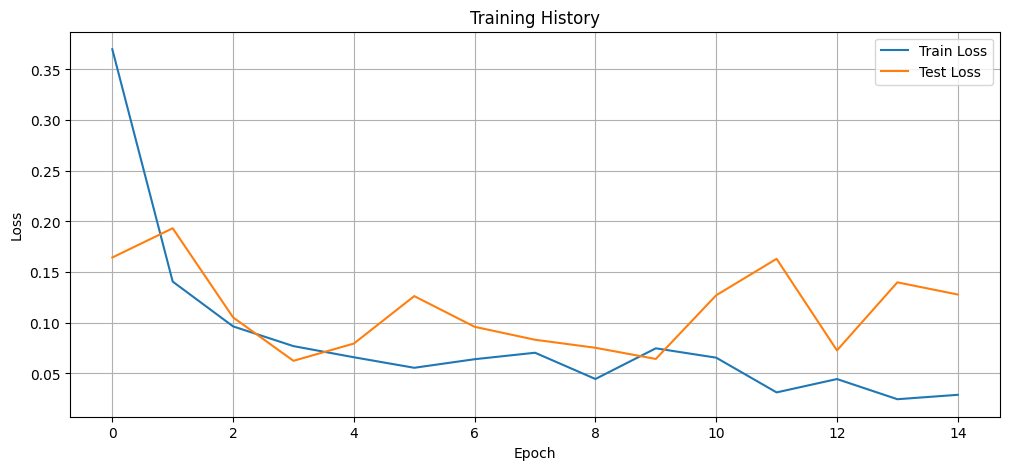

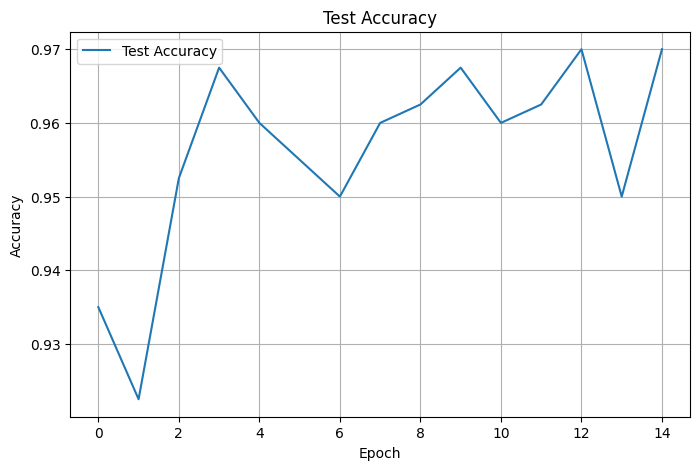

In [14]:
plt.figure(figsize=(12,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

##Counterfactual prediction function

In [15]:
def predict_counterfactual_outcomes(model, patient_x, num_treatments=3):
    """
    patient_x: [seq_len, num_features]
    Returns predicted risk probability for each treatment choice
    """
    model.eval()
    results = {}

    with torch.no_grad():
        x_tensor = torch.tensor(patient_x, dtype=torch.float32).unsqueeze(0).to(device)  # [1, S, F]

        seq_len = patient_x.shape[0]

        for tr in range(num_treatments):
            t_tensor = torch.full((1, seq_len), tr, dtype=torch.long).to(device)
            logits = model(x_tensor, t_tensor)
            prob = torch.sigmoid(logits).item()
            results[tr] = prob

    return results

##Test on one patient

In [16]:
sample_idx = 0
patient_x = X_test[sample_idx]

results = predict_counterfactual_outcomes(model, patient_x, num_treatments=num_treatments)

treatment_names = {
    0: "No Treatment",
    1: "Drug A",
    2: "Drug B"
}

print("Counterfactual prediction for same patient:")
for k, v in results.items():
    label = "Risky" if v > 0.5 else "Stable"
    print(f"{treatment_names[k]} -> Risk Probability: {v:.4f} -> Predicted Outcome: {label}")

Counterfactual prediction for same patient:
No Treatment -> Risk Probability: 0.9994 -> Predicted Outcome: Risky
Drug A -> Risk Probability: 0.9994 -> Predicted Outcome: Risky
Drug B -> Risk Probability: 0.9994 -> Predicted Outcome: Risky


##Visualize counterfactual comparison

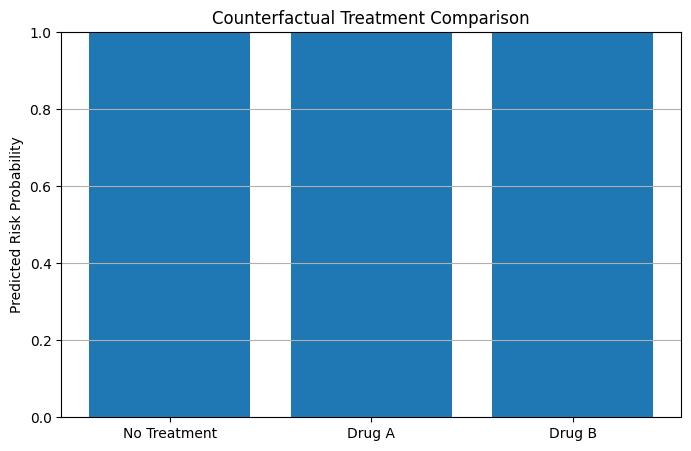

In [17]:
labels = [treatment_names[k] for k in results.keys()]
values = [results[k] for k in results.keys()]

plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.ylabel("Predicted Risk Probability")
plt.title("Counterfactual Treatment Comparison")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

##Show patient trajectory

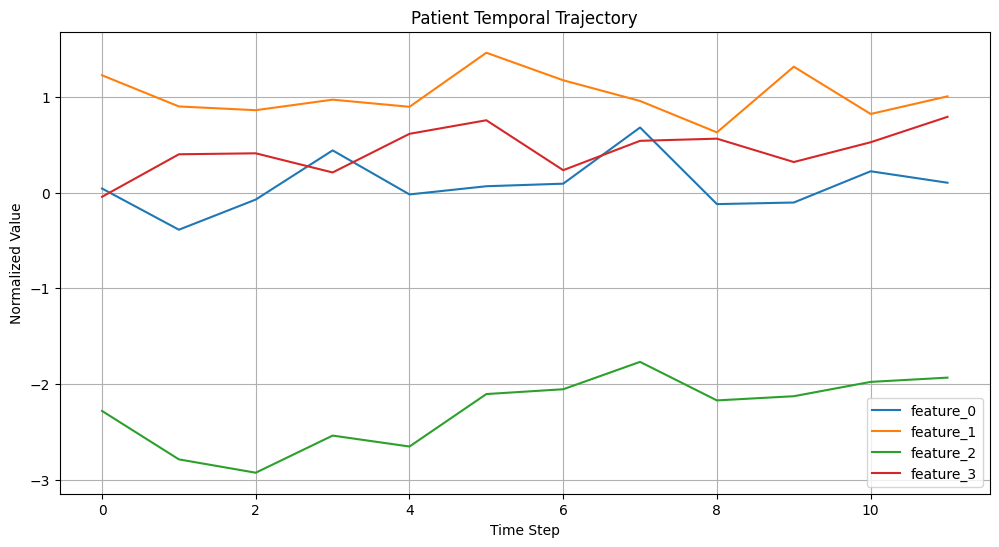

In [18]:
patient_df = pd.DataFrame(patient_x, columns=[f"feature_{i}" for i in range(num_features)])

plt.figure(figsize=(12,6))
for i in range(min(4, num_features)):
    plt.plot(patient_df.index, patient_df[f"feature_{i}"], label=f"feature_{i}")

plt.xlabel("Time Step")
plt.ylabel("Normalized Value")
plt.title("Patient Temporal Trajectory")
plt.legend()
plt.grid(True)
plt.show()

##Generate table output

In [19]:
summary_rows = []

for tr, prob in results.items():
    summary_rows.append({
        "Treatment": treatment_names[tr],
        "Predicted Risk Probability": round(prob, 4),
        "Predicted Outcome": "Risky" if prob > 0.5 else "Stable"
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Treatment,Predicted Risk Probability,Predicted Outcome
0,No Treatment,0.9994,Risky
1,Drug A,0.9994,Risky
2,Drug B,0.9994,Risky
